#**`Supply Chain & Logistics`**




The data set has 53 features and 180520 attributes

Target columns :

*   Days for shipping(real)







###Columns to be dropped

*   type
*   benifit per oder
*   sale per customer
*   category ID
*   category name
*    Customer country
*   customer email
*    Customer Fname
*   customer ID
*   customer Lname
*   customer password
*   customer state
*   customer street
*   customer zipcode
*   departmeny name
*   order country
*    order customer id
*    order data(date orders)
*   Order Id
*   order  item cardprod id
*   order item discount
*   order item discount rate
*   order item id
*    order item product price
*    order item product ratio
*    order item quantity
*    sale
*    order item total
*    order profit per order
*    order region
*    order state

*    order zipcode(more null value)
*    product card id
*    product category id
*    product  description
*    product image
*    product name
*    product price
*    product status


In Shipping date we extract from that column and then remove the orginal coulmn








###Columns Retained
*    Days of shippement(real)  - Target
*    Days of shippement(scheduled)
*    Delivery status
*    Late_Delivery_Risk
*    Customer city
*    Customer Segment → Helps analyze delivery performance across customer types
*   Department ID → Product category ID may influence logistics time
*   Latitude
*   Longitude
*   Market → Different markets may have different shipping efficiency

*   order status
*   shipping date (extract)
*   Shipping Mode





  





# Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/DataCoSupplyChainDataset.csv',encoding='latin')
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


# Preprocessing

In [ ]:
df_eda = ['Days for shipping (real)','Days for shipment (scheduled)',
                        'Latitude','Longitude','Shipping Mode',
                        'Order Region','Market',
                        'shipping date (DateOrders)','Department Id',]

In [ ]:
df_eda = df[df_eda]

In [ ]:
df_eda.head()

,Days for shipping (real),Days for shipment (scheduled),Latitude,Longitude,Shipping Mode,Order Region,Market,shipping date (DateOrders),Department Id
0,3,4,18.251453,-66.037056,Standard Class,Southeast Asia,Pacific Asia,2/3/2018 22:56,2
1,5,4,18.279451,-66.037064,Standard Class,South Asia,Pacific Asia,1/18/2018 12:27,2
2,4,4,37.292233,-121.881279,Standard Class,South Asia,Pacific Asia,1/17/2018 12:06,2
3,3,4,34.125946,-118.291016,Standard Class,Oceania,Pacific Asia,1/16/2018 11:45,2
4,2,4,18.253769,-66.037048,Standard Class,Oceania,Pacific Asia,1/15/2018 11:24,2


In [ ]:
df_eda.isnull().sum()

,0
Days for shipping (real),0
Days for shipment (scheduled),0
Latitude,0
Longitude,0
Shipping Mode,0
Order Region,0
Market,0
shipping date (DateOrders),0
Department Id,0


In [ ]:
df_eda['shipping date (DateOrders)'] = pd.to_datetime(df_eda['shipping date (DateOrders)'], format='mixed')
df_eda['shipping date (DateOrders)']

/tmp/ipykernel_638/969883419.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eda['shipping date (DateOrders)'] = pd.to_datetime(df_eda['shipping date (DateOrders)'], format='mixed')


,shipping date (DateOrders)
0,2018-02-03 22:56:00
1,2018-01-18 12:27:00
2,2018-01-17 12:06:00
3,2018-01-16 11:45:00
4,2018-01-15 11:24:00
...,...
180514,2016-01-20 03:40:00
180515,2016-01-19 01:34:00
180516,2016-01-20 21:00:00
180517,2016-01-18 20:18:00


## Extracting shipping date and time

In [ ]:

df_eda['shipping_year'] = df_eda['shipping date (DateOrders)'].dt.year
df_eda['shipping_month'] = df_eda['shipping date (DateOrders)'].dt.month

df_eda['shipping_day'] = df_eda['shipping date (DateOrders)'].dt.day
df_eda['shipping_weekdays'] = df_eda['shipping date (DateOrders)'].dt.day_name()

/tmp/ipykernel_638/3905408098.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eda['shipping_year'] = df_eda['shipping date (DateOrders)'].dt.year
/tmp/ipykernel_638/3905408098.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eda['shipping_month'] = df_eda['shipping date (DateOrders)'].dt.month
/tmp/ipykernel_638/3905408098.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in 

In [ ]:
df_eda.columns

Index(['Days for shipping (real)', 'Days for shipment (scheduled)', 'Latitude',
       'Longitude', 'Shipping Mode', 'Order Region', 'Market',
       'shipping date (DateOrders)', 'Department Id', 'shipping_year',
       'shipping_month', 'shipping_day', 'shipping_weekdays'],
      dtype='object')

In [ ]:
df_eda.drop(['shipping date (DateOrders)'],axis=1,inplace=True)

/tmp/ipykernel_638/2336175955.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eda.drop(['shipping date (DateOrders)'],axis=1,inplace=True)


In [ ]:
df_eda.head()

,Days for shipping (real),Days for shipment (scheduled),Latitude,Longitude,Shipping Mode,Order Region,Market,Department Id,shipping_year,shipping_month,shipping_day,shipping_weekdays
0,3,4,18.251453,-66.037056,Standard Class,Southeast Asia,Pacific Asia,2,2018,2,3,Saturday
1,5,4,18.279451,-66.037064,Standard Class,South Asia,Pacific Asia,2,2018,1,18,Thursday
2,4,4,37.292233,-121.881279,Standard Class,South Asia,Pacific Asia,2,2018,1,17,Wednesday
3,3,4,34.125946,-118.291016,Standard Class,Oceania,Pacific Asia,2,2018,1,16,Tuesday
4,2,4,18.253769,-66.037048,Standard Class,Oceania,Pacific Asia,2,2018,1,15,Monday


In [ ]:
cat_cols = df_eda.select_dtypes(include='object').columns
cat_cols

Index(['Shipping Mode', 'Order Region', 'Market', 'shipping_weekdays'], dtype='object')

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

columns_to_encode = ['Shipping Mode', 'Order Region',
                     'Market', 'shipping_weekdays']

# Initialize encoder
encoder = OneHotEncoder(drop='first', sparse_output=False)

# Fit and transform only selected columns
encoded_array = encoder.fit_transform(df_eda[columns_to_encode])

# Get new column names
encoded_columns = encoder.get_feature_names_out(columns_to_encode)

# Convert to DataFrame
encoded_df = pd.DataFrame(encoded_array,
                          columns=encoded_columns,
                          index=df.index)

# Drop original columns and concatenate encoded columns
df_eda = pd.concat([df_eda.drop(columns=columns_to_encode),
                      encoded_df], axis=1)

print(df_eda.head())

   Days for shipping (real)  Days for shipment (scheduled)   Latitude  \
0                         3                              4  18.251453   
1                         5                              4  18.279451   
2                         4                              4  37.292233   
3                         3                              4  34.125946   
4                         2                              4  18.253769   

    Longitude  Department Id  shipping_year  shipping_month  shipping_day  \
0  -66.037056              2           2018               2             3   
1  -66.037064              2           2018               1            18   
2 -121.881279              2           2018               1            17   
3 -118.291016              2           2018               1            16   
4  -66.037048              2           2018               1            15   

   Shipping Mode_Same Day  Shipping Mode_Second Class  ...  Market_Europe  \
0                    

In [ ]:
df_eda.head()

,Days for shipping (real),Days for shipment (scheduled),Latitude,Longitude,Department Id,shipping_year,shipping_month,shipping_day,Shipping Mode_Same Day,Shipping Mode_Second Class,...,Market_Europe,Market_LATAM,Market_Pacific Asia,Market_USCA,shipping_weekdays_Monday,shipping_weekdays_Saturday,shipping_weekdays_Sunday,shipping_weekdays_Thursday,shipping_weekdays_Tuesday,shipping_weekdays_Wednesday
0,3,4,18.251453,-66.037056,2,2018,2,3,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,5,4,18.279451,-66.037064,2,2018,1,18,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,4,4,37.292233,-121.881279,2,2018,1,17,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3,4,34.125946,-118.291016,2,2018,1,16,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2,4,18.253769,-66.037048,2,2018,1,15,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Days for shipping (real)       180519 non-null  int64  
 1   Days for shipment (scheduled)  180519 non-null  int64  
 2   Latitude                       180519 non-null  float64
 3   Longitude                      180519 non-null  float64
 4   Department Id                  180519 non-null  int64  
 5   shipping_year                  180519 non-null  int32  
 6   shipping_month                 180519 non-null  int32  
 7   shipping_day                   180519 non-null  int32  
 8   Shipping Mode_Same Day         180519 non-null  float64
 9   Shipping Mode_Second Class     180519 non-null  float64
 10  Shipping Mode_Standard Class   180519 non-null  float64
 11  Order Region_Caribbean         180519 non-null  float64
 12  Order Region_Central Africa   

In [ ]:
#bool_cols = df_eda.select_dtypes(include='bool').columns
#df_eda[bool_cols] = df_eda[bool_cols].astype(int)

In [ ]:
df_eda.head(10)

,Days for shipping (real),Days for shipment (scheduled),Latitude,Longitude,Department Id,shipping_year,shipping_month,shipping_day,Shipping Mode_Same Day,Shipping Mode_Second Class,...,Market_Europe,Market_LATAM,Market_Pacific Asia,Market_USCA,shipping_weekdays_Monday,shipping_weekdays_Saturday,shipping_weekdays_Sunday,shipping_weekdays_Thursday,shipping_weekdays_Tuesday,shipping_weekdays_Wednesday
0,3,4,18.251453,-66.037056,2,2018,2,3,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,5,4,18.279451,-66.037064,2,2018,1,18,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,4,4,37.292233,-121.881279,2,2018,1,17,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3,4,34.125946,-118.291016,2,2018,1,16,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2,4,18.253769,-66.037048,2,2018,1,15,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5,6,4,43.013969,-78.879066,2,2018,1,19,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,2,1,18.242538,-66.037056,2,2018,1,15,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7,2,1,25.928869,-80.162872,2,2018,1,15,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
8,3,2,18.233223,-66.037056,2,2018,1,16,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9,2,1,37.773991,-121.966629,2,2018,1,15,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


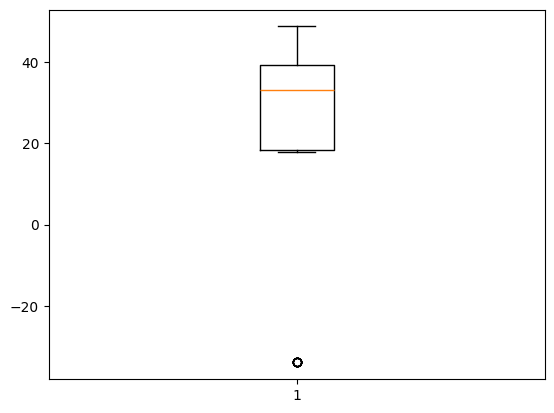

In [ ]:
plt.boxplot(df_eda['Latitude'])
plt.show()

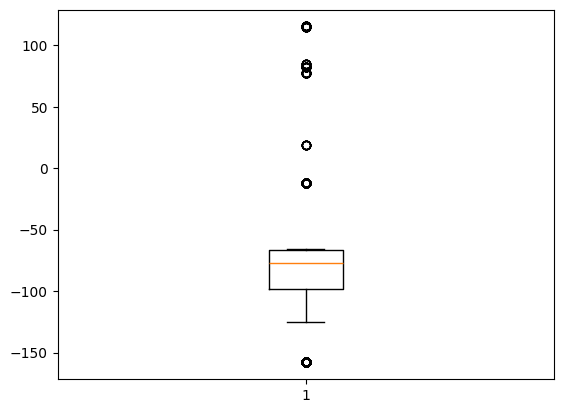

In [ ]:
plt.boxplot(df_eda['Longitude'])
plt.show()

In [ ]:
#import numpy as np
#df_eda['Latitude'] = np.log1p(df_eda['Latitude'])

In [ ]:
#df_eda.head()

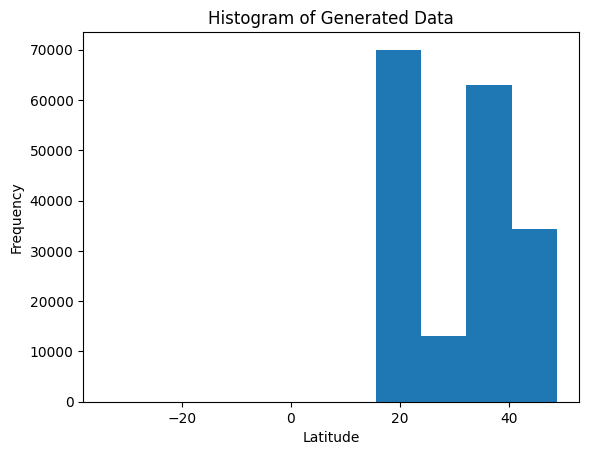

In [ ]:
plt.hist(df_eda['Latitude'] )

# Add labels and a title
plt.xlabel('Latitude')
plt.ylabel('Frequency')
plt.title('Histogram of Generated Data')
plt.show()

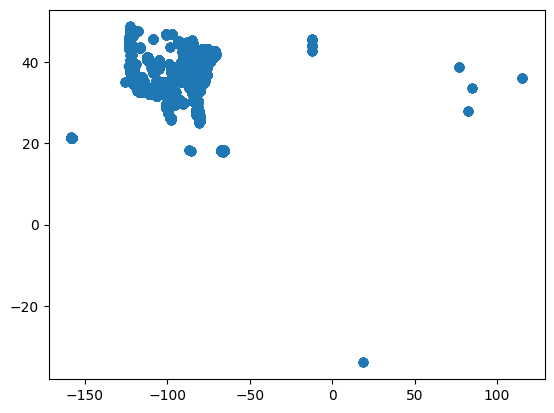

In [ ]:
plt.scatter(df_eda['Longitude'],df_eda['Latitude'])

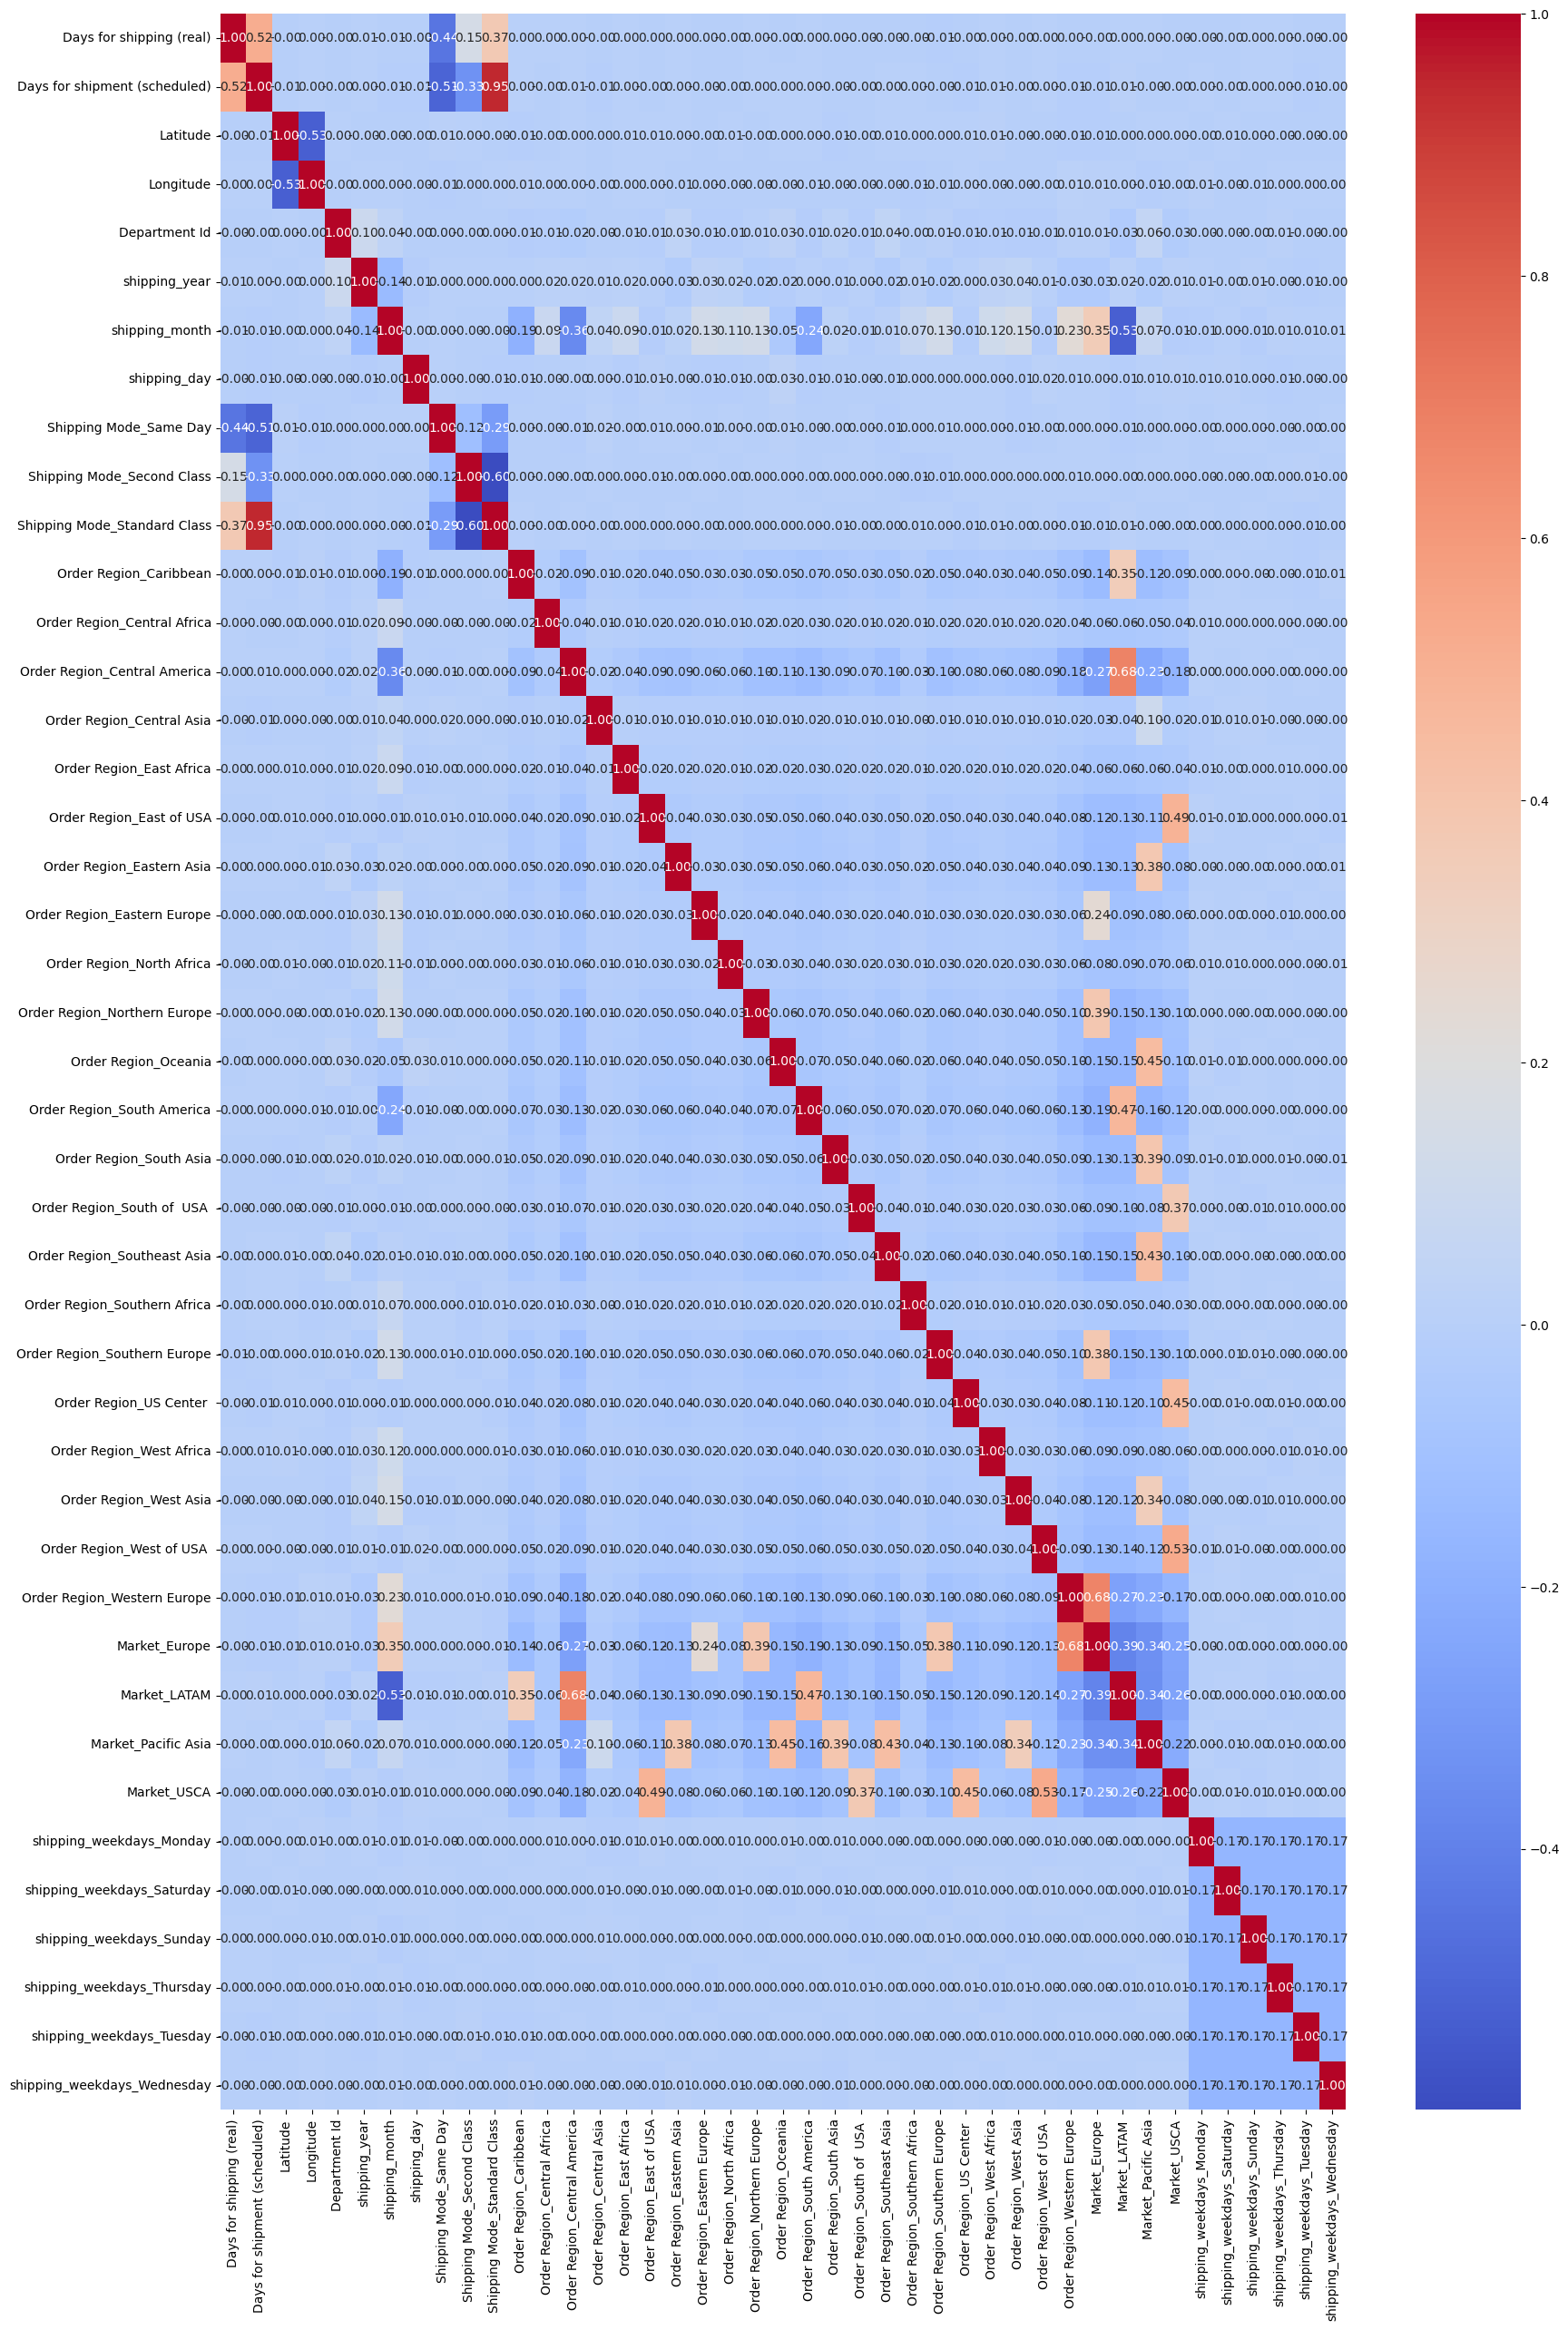

In [ ]:
corrmap = df_eda.corr(numeric_only=True) # correlation heat map
top=corrmap.index
plt.figure(figsize=(20,30))
g=sns.heatmap(df_eda[top].corr(),annot=True,cmap="coolwarm",fmt=".2f")

In [ ]:
df_eda['Days for shipping (real)'].value_counts()

,count
Days for shipping (real),
2,56618
3,28765
6,28723
4,28513
5,28163
0,5080
1,4657


## Training and splitting

In [ ]:
x = df_eda.drop(['Days for shipping (real)'],axis= 1)
y = df_eda['Days for shipping (real)']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42, stratify=y)

#Modelling--RFregressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
model = RandomForestRegressor(random_state=42)
model.fit(x_train,y_train)

RandomForestRegressor(random_state=42)

In [ ]:
rf_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error

In [ ]:
rf_mse = mean_squared_error(y_test,rf_pred)

In [ ]:
rf_mse

0.3496952415769083

In [ ]:
r2_score = r2_score(y_test,rf_pred)
r2_score

0.8673605054908649

In [ ]:
rf_mae = mean_absolute_error(y_test,rf_pred)
rf_mae

0.33978145212771566

#DT-regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
model1 = DecisionTreeRegressor()
model1.fit(x_train,y_train)

DecisionTreeRegressor()

In [ ]:
dt_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error

In [ ]:
dt_mse = mean_squared_error(y_test,dt_pred)
print(dt_mse)
dt_r2_score = r2_score(y_test,dt_pred)
print(dt_r2_score)
dt_mae = mean_absolute_error(y_test,dt_pred)
print(dt_mae)

0.3496952415769083
0.8673605054908649
0.33978145212771566


In [ ]:
#xg boost
from xgboost import XGBRegressor
model_xg = XGBRegressor()
model_xg.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xg_pred = model_xg.predict(x_test)

In [ ]:
xg_mse = mean_squared_error(y_test,xg_pred)
print(xg_mse)
xg_r2_score = r2_score(y_test,xg_pred)
print(xg_r2_score)
xg_mae = mean_absolute_error(y_test,xg_pred)
print(xg_mae)

1.4324932098388672
0.45665496587753296
0.9505833983421326


In [ ]:
#gradient boosting
from sklearn.ensemble import GradientBoostingRegressor
model_gb = GradientBoostingRegressor()
model_gb.fit(x_train,y_train)

GradientBoostingRegressor()

In [ ]:
gb_pred = model_gb.predict(x_test)

In [ ]:
gb_mse = mean_squared_error(y_test,gb_pred)
print(gb_mse)
gb_r2_score = r2_score(y_test,gb_pred)
print(gb_r2_score)
gb_mae = mean_absolute_error(y_test,gb_pred)
print(gb_mae)

1.600167069544268
0.39305622153329556
0.986681038830393


In [ ]:
from sklearn.model_selection import GridSearchCV



In [ ]:
param_grid = {
    'n_estimators': [100,200],     #number of trees in the Random Forest.
    'max_depth': [ None,10,20],    #controls how deep each decision tree can grow.
    'min_samples_split': [2,5],     #Minimum number of samples required to split a node.
    'min_samples_leaf':[1,2]          #Minimum number of samples required in a leaf node.
}
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,                             #3-fold cross validation.
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(x_train, y_train)
print("Best parameters: ", grid_search.best_params_)
best_rf = grid_search.best_estimator_

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters:  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
y_pred_best = best_rf.predict(x_test)
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import numpy as np

print('Tuned Random Forest ')
print('MSE: ',mean_squared_error(y_test,y_pred_best))
print('MAE: ',mean_absolute_error(y_test,y_pred_best))
print('RMSE: ',np.sqrt(mean_squared_error(y_test,y_pred_best) ))
print('R2:',r2_score(y_test,y_pred_best))

Tuned Random Forest 
MSE:  0.34613536455080823
MAE:  0.3382992006627719
RMSE:  0.5883326988624789
R2: 0.8687107677567378


In [ ]:
print('Baseline RMSE:',np.sqrt(mean_squared_error(y_test,rf_pred)))
print('Tuned RMSE:',np.sqrt(mean_squared_error(y_test,y_pred_best)))

Baseline RMSE: 0.5913503543390402
Tuned RMSE: 0.5883326988624789


<Axes: ylabel='Days for shipping (real)'>

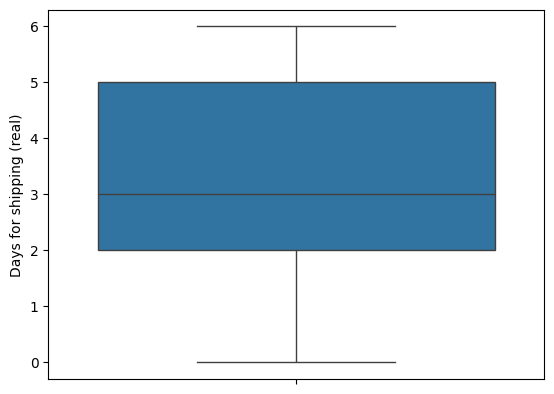

In [ ]:
sns.boxplot(df_eda['Days for shipping (real)'])

In [ ]:
print("Train R2:", r2_score(y_train, best_rf.predict(x_train)))   #Calculates how well model fits the training data.
print("Test R2:", r2_score(y_test, y_pred_best))     #Calculates how well model performs on unseen test data.
#Difference

Train R2: 0.9817262263745966
Test R2: 0.8687107677567378


In [ ]:
result_df = pd.DataFrame({
    'model':['Random Forest','Best Random Forest'],
    'MSE':[rf_mse,mean_squared_error(y_test,y_pred_best)],
    'MAE':[rf_mae,mean_absolute_error(y_test,y_pred_best)],
    'R2_Score':[r2_score(y_test,rf_pred),r2_score(y_test,y_pred_best)]

})


In [ ]:
result_df

,model,MSE,MAE,R2_Score
0,Random Forest,0.349695,0.339781,0.867361
1,Best Random Forest,0.346135,0.338299,0.868711


In [ ]:
import pickle   # for saving it


In [ ]:
print(best_rf)

RandomForestRegressor(n_estimators=200, random_state=42)


In [ ]:
with open('tuned_random_forest.pkl','wb') as f:
  pickle.dump(best_rf,f)

In [ ]:
print(best_rf.feature_names_in_)

['Days for shipment (scheduled)' 'Latitude' 'Longitude' 'Department Id'
 'shipping_year' 'shipping_month' 'shipping_day' 'Shipping Mode_Same Day'
 'Shipping Mode_Second Class' 'Shipping Mode_Standard Class'
 'Order Region_Caribbean' 'Order Region_Central Africa'
 'Order Region_Central America' 'Order Region_Central Asia'
 'Order Region_East Africa' 'Order Region_East of USA'
 'Order Region_Eastern Asia' 'Order Region_Eastern Europe'
 'Order Region_North Africa' 'Order Region_Northern Europe'
 'Order Region_Oceania' 'Order Region_South America'
 'Order Region_South Asia' 'Order Region_South of  USA '
 'Order Region_Southeast Asia' 'Order Region_Southern Africa'
 'Order Region_Southern Europe' 'Order Region_US Center '
 'Order Region_West Africa' 'Order Region_West Asia'
 'Order Region_West of USA ' 'Order Region_Western Europe' 'Market_Europe'
 'Market_LATAM' 'Market_Pacific Asia' 'Market_USCA'
 'shipping_weekdays_Monday' 'shipping_weekdays_Saturday'
 'shipping_weekdays_Sunday' 'shippin